In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [4]:
distory = pd.read_csv("./data/DisasterStory.csv")

inputem = pd.read_excel("./data/input_emdat_1424.xlsx")

# Make sure DisNo. is comparable
inputem['DisNo.'] = inputem['DisNo.'].astype(str)
distory['DisNo.'] = distory['DisNo.'].astype(str)

# Restrict EM-DAT to your study period if needed
inputem_14_24 = inputem[
    (inputem['Start Year'] >= 2014) &
    (inputem['Start Year'] <= 2024)
]

In [28]:
inputem.columns

Index(['DisNo.', 'Historic', 'Classification Key', 'Disaster Group',
       'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype',
       'External IDs', 'Event Name', 'ISO', 'Country', 'Subregion', 'Region',
       'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal',
       'Declaration', 'AID Contribution ('000 US$)', 'Magnitude',
       'Magnitude Scale', 'Latitude', 'Longitude', 'River Basin', 'Start Year',
       'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day',
       'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless',
       'Total Affected', 'Reconstruction Costs ('000 US$)',
       'Reconstruction Costs, Adjusted ('000 US$)',
       'Insured Damage ('000 US$)', 'Insured Damage, Adjusted ('000 US$)',
       'Total Damage ('000 US$)', 'Total Damage, Adjusted ('000 US$)', 'CPI',
       'Admin Units', 'GADM Admin Units', 'Entry Date', 'Last Update'],
      dtype='object')

In [5]:
overall_coverage = (
    inputem_14_24['DisNo.']
    .isin(distory['DisNo.'])
    .mean()
)

overall_coverage

0.5054487179487179

In [10]:
# Total EM-DAT counts by disaster type
em_by_type = (
    inputem_14_24
    .groupby('Disaster Type')['DisNo.']
    .nunique()
    .rename('emdat_total')
)

# Output counts by disaster type
out_by_type = (
    inputem_14_24[inputem_14_24['DisNo.'].isin(distory['DisNo.'])]
    .groupby('Disaster Type')['DisNo.']
    .nunique()
    .rename('story_total')
)

coverage_type = (
    pd.concat([em_by_type, out_by_type], axis=1)
      .fillna(0)
      .assign(coverage=lambda df: df['story_total'] / df['emdat_total'])
      .sort_values('coverage', ascending=False)
)

coverage_type

,emdat_total,story_total,coverage
Disaster Type,,,
Mass movement (dry),4,4.0,1.000000
Glacial lake outburst flood,5,5.0,1.000000
Earthquake,272,228.0,0.838235
Wildfire,147,122.0,0.829932
Rail,70,53.0,0.757143
Explosion (Industrial),82,61.0,0.743902
Explosion (Miscellaneous),42,30.0,0.714286
Collapse (Miscellaneous),50,35.0,0.700000
Volcanic activity,55,38.0,0.690909


In [8]:
coverage_region = (
    inputem_14_24
    .assign(in_story=lambda df: df['DisNo.'].isin(distory['DisNo.']))
    .groupby('Subregion')
    .agg(
        emdat_total=('DisNo.', 'nunique'),
        story_total=('in_story', 'sum')
    )
    .assign(coverage=lambda df: df['story_total'] / df['emdat_total'])
    .sort_values('coverage', ascending=False)
)

coverage_region

,emdat_total,story_total,coverage
Subregion,,,
Australia and New Zealand,71,60,0.845070
Northern America,359,289,0.805014
Southern Asia,835,535,0.640719
South-eastern Asia,755,481,0.637086
Melanesia,62,37,0.596774
Eastern Asia,581,325,0.559380
Central Asia,48,26,0.541667
Western Asia,275,132,0.480000
Latin America and the Caribbean,994,416,0.418511


In [9]:
coverage_year = (
    inputem_14_24
    .assign(in_story=lambda df: df['DisNo.'].isin(distory['DisNo.']))
    .groupby('Start Year')
    .agg(
        emdat_total=('DisNo.', 'nunique'),
        story_total=('in_story', 'sum')
    )
    .assign(coverage=lambda df: df['story_total'] / df['emdat_total'])
)

coverage_year

,emdat_total,story_total,coverage
Start Year,,,
2014,547,174,0.318099
2015,601,282,0.469218
2016,534,272,0.509363
2017,544,290,0.533088
2018,497,267,0.537223
2019,608,298,0.490132
2020,515,226,0.438835
2021,588,333,0.566327
2022,595,320,0.537815


In [25]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Global style (once)
sns.set(style="whitegrid")
plt.rcParams.update({'font.size': 20})

# Ensure output directory exists
os.makedirs("./plots", exist_ok=True)


def plot_coverage_barh(
    df,
    category_col,
    min_events=10,
    bar_color='#6BAED6',
    title='',
    filename=''
):
    plot_df = (
        df
        .reset_index()
        .query("emdat_total >= @min_events")
        .copy()
    )

    # Sort logic: chronological for years, coverage otherwise
    if 'year' in category_col.lower():
        plot_df = plot_df.sort_values(category_col)
    else:
        plot_df = plot_df.sort_values("coverage", ascending=True)

    plot_df['coverage_pct'] = 100 * plot_df['coverage']

    plt.figure(figsize=(10, 7))
    plt.barh(
        range(len(plot_df)),
        plot_df['coverage_pct'],
        color=bar_color
    )

    ax = plt.gca()

    # Force all y-ticks (critical for years)
    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels(plot_df[category_col])

    # Labels
    plt.xlabel('Coverage of EM-DAT events (%)', fontsize=20)
    plt.ylabel('')
    plt.title(title, fontsize=20, weight='bold')

    # Tick sizes
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    # Annotate bars
    for i, row in plot_df.iterrows():
        y_pos = plot_df.index.get_loc(i)
        plt.text(
            row['coverage_pct'] + 1,
            y_pos,
            f"{row['coverage_pct']:.1f}%",
            va='center',
            fontsize=14
        )

    sns.despine(left=True, bottom=True)
    plt.tight_layout()

    plt.savefig(
        f"./plots/{filename}",
        dpi=300,
        bbox_inches='tight',
        format='png'
    )
    plt.close()

In [21]:
plot_coverage_barh(
    coverage_region,
    category_col='Subregion',
    min_events=10,
    bar_color='#6BAED6',
    title='Coverage by world region',
    filename='coverage_region.png'
)

In [22]:
plot_coverage_barh(
    coverage_type,
    category_col='Disaster Type',
    min_events=10,
    bar_color='#6BAED6',
    title='Coverage by disaster type',
    filename='coverage_disaster_type.png'
)

In [26]:
plot_coverage_barh(
    coverage_year,
    category_col='Start Year',
    min_events=10,
    bar_color='#6BAED6',
    title='Coverage by year',
    filename='coverage_year.png'
)

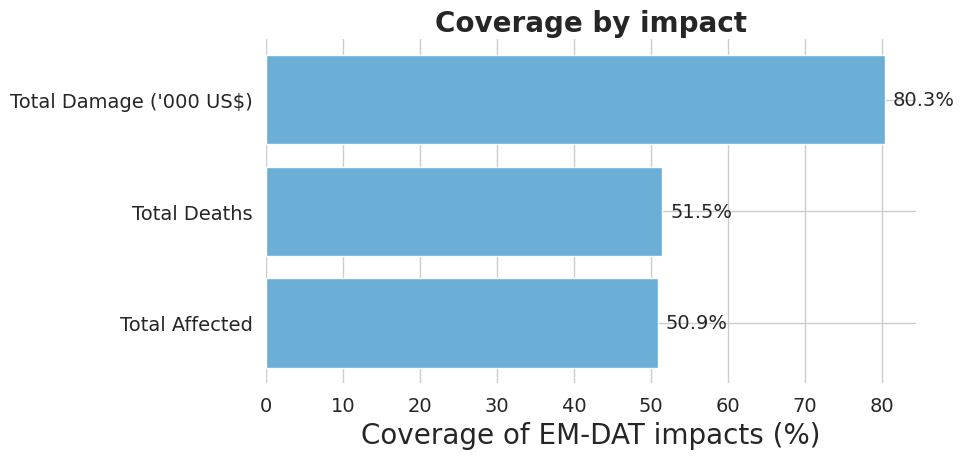

In [39]:

# Global style
sns.set(style="whitegrid")
plt.rcParams.update({'font.size': 20})

# Ensure output directory exists
os.makedirs("./plots", exist_ok=True)

# Compute coverage for each impact
impact_cols = [
    'Total Deaths',
    'Total Affected',
    "Total Damage ('000 US$)"
]

impact_coverage = {}
for col in impact_cols:
    total_emdat = inputem[col].sum()
    total_story = inputem.loc[
        inputem['DisNo.'].isin(distory['DisNo.']),
        col
    ].sum()
    coverage = total_story / total_emdat if total_emdat > 0 else 0
    impact_coverage[col] = coverage

# Convert to DataFrame for plotting
impact_df = pd.DataFrame({
    'Impact': list(impact_coverage.keys()),
    'Coverage': [v*100 for v in impact_coverage.values()]  # percent
}).sort_values('Coverage')

# Plot
plt.figure(figsize=(10, 5))
bar_color = '#6BAED6'
ax = plt.barh(impact_df['Impact'], impact_df['Coverage'], color=bar_color)

plt.xlabel('Coverage of EM-DAT impacts (%)', fontsize=20)
plt.ylabel('')
plt.title('Coverage by impact', fontsize=20, weight='bold')

# Increase tick label sizes
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Annotate bars
for i, row in impact_df.iterrows():
    plt.text(
        row['Coverage'] + 1,
        row['Impact'],
        f"{row['Coverage']:.1f}%",
        va='center',
        fontsize=14
    )

sns.despine(left=True, bottom=True)
plt.tight_layout()

# Save figure
plt.savefig("./plots/coverage_by_impact.png", dpi=300, bbox_inches='tight', format='png')
plt.show()

In [42]:
coverage_year

,emdat_total,story_total,coverage
Start Year,,,
2014,547,174,0.318099
2015,601,282,0.469218
2016,534,272,0.509363
2017,544,290,0.533088
2018,497,267,0.537223
2019,608,298,0.490132
2020,515,226,0.438835
2021,588,333,0.566327
2022,595,320,0.537815
